# Notebook 4 - Analisis Correlacional de Polarizacion

La hipotesis H4 plantea que los contenidos desinformativos se distinguen por mayor carga emocional y lenguaje de alarma, no solo por su veracidad. Aqui lo probamos directamente.

Usamos VADER (disenado especificamente para redes sociales) y TextBlob para el sentimiento, mas un conjunto de indicadores lexicos propios. Los tests de Kruskal-Wallis y Mann-Whitney confirman si las diferencias entre clases son estadisticamente significativas.

**Nota:** trabajamos sobre el dataset completo (96,936 tweets), no solo source tweets, porque las reactions son parte del fenomeno de polarizacion.


## 0. Instalación de dependencias

In [1]:
# Ejecutar solo si no estan instaladas
# import sys
# !{sys.executable} -m pip install vaderSentiment textblob scipy

## 1. Imports y configuración

In [2]:
import os
import re
import pickle
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from collections import Counter

from scipy import stats
from scipy.stats import kruskal, mannwhitneyu

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

RANDOM_STATE = 42

BASE_DIR      = os.path.abspath(os.path.join(os.getcwd(), '..'))
RESULTS_DIR   = os.path.join(BASE_DIR, 'results')
PROCESSED_DIR = os.path.join(BASE_DIR, 'data', 'processed')

os.makedirs(RESULTS_DIR, exist_ok=True)

# Colores por clase
CLASS_COLORS = {
    'false':      '#e74c3c',
    'true':       '#2ecc71',
    'unverified': '#f39c12',
    'non-rumour': '#3498db',
}

print(f'Base dir: {BASE_DIR}')
print('Imports OK')

Base dir: C:\Users\danie\PycharmProjects\TratamientoDatosMayo
Imports OK


## 2. Carga de datos

In [3]:
df = pd.read_csv(os.path.join(PROCESSED_DIR, 'pheme_clean.csv'))

print(f'Dataset: {len(df):,} tweets')
print(f'Clases de veracidad: {df["veracity"].unique()}')
print(f'Tipos de tweet: {df["tweet_type"].unique()}')
print()
print('Distribucion:')
print(df['veracity'].value_counts().to_string())

Dataset: 96,936 tweets
Clases de veracidad: <StringArray>
['true', 'unverified', 'false', 'non-rumour']
Length: 4, dtype: str
Tipos de tweet: <StringArray>
['source', 'reaction']
Length: 2, dtype: str

Distribucion:
veracity
non-rumour    66522
true          14042
unverified    10438
false          5934


## 3. Análisis de sentimiento con VADER

In [4]:
# VADER es ideal para tweets: maneja mayusculas, emojis, puntuacion
analyzer = SentimentIntensityAnalyzer()

def get_vader_scores(text: str) -> dict:
    scores = analyzer.polarity_scores(str(text))
    return {
        'vader_neg':      scores['neg'],
        'vader_neu':      scores['neu'],
        'vader_pos':      scores['pos'],
        'vader_compound': scores['compound'],
    }

print('Calculando scores VADER...')
vader_scores = [get_vader_scores(t) for t in tqdm(df['text'], desc='VADER')]
df_vader     = pd.DataFrame(vader_scores)
df          = pd.concat([df.reset_index(drop=True), df_vader], axis=1)

print('Hecho.')
print(df.groupby('veracity')[['vader_neg', 'vader_pos', 'vader_compound']].mean().round(3).to_string())

Calculando scores VADER...


VADER: 100%|██████████| 96936/96936 [00:02<00:00, 35251.39it/s]

Hecho.
            vader_neg  vader_pos  vader_compound
veracity                                        
false           0.117      0.094          -0.068
non-rumour      0.123      0.109          -0.059
true            0.132      0.097          -0.100
unverified      0.124      0.080          -0.124


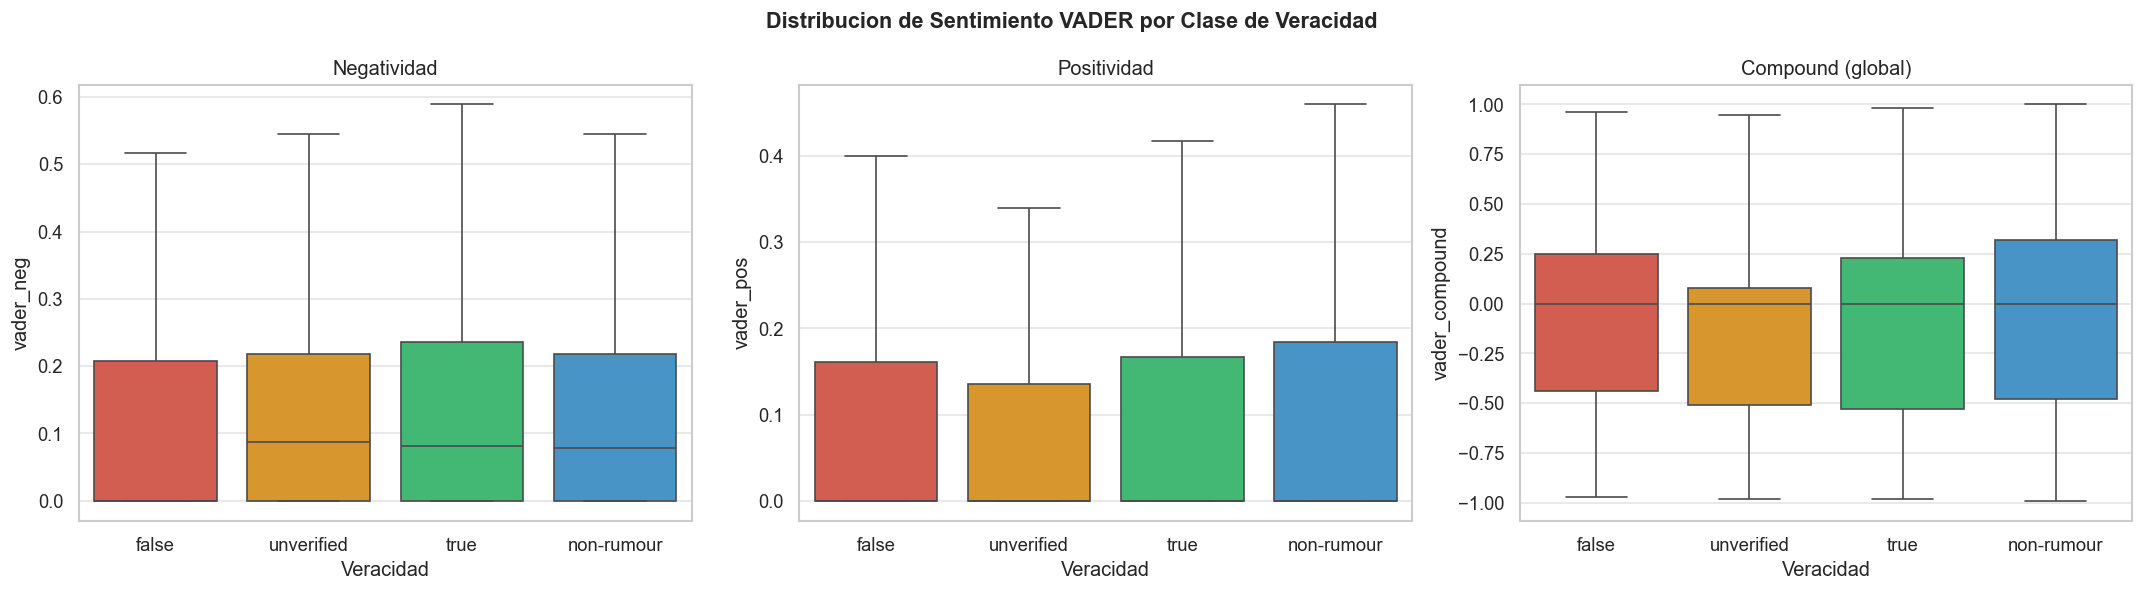

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribucion de Sentimiento VADER por Clase de Veracidad',
             fontsize=13, fontweight='bold')

metrics = [
    ('vader_neg',      'Negatividad'),
    ('vader_pos',      'Positividad'),
    ('vader_compound', 'Compound (global)'),
]

ver_order = ['false', 'unverified', 'true', 'non-rumour']
ver_order = [v for v in ver_order if v in df['veracity'].unique()]
palette   = [CLASS_COLORS[v] for v in ver_order]

for ax, (col, title) in zip(axes, metrics):
    sns.boxplot(data=df, x='veracity', y=col, order=ver_order,
                palette=palette, ax=ax, showfliers=False)
    ax.set_title(title)
    ax.set_xlabel('Veracidad')
    ax.set_ylabel(col)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '22_vader_by_veracity.png'), bbox_inches='tight')
plt.show()

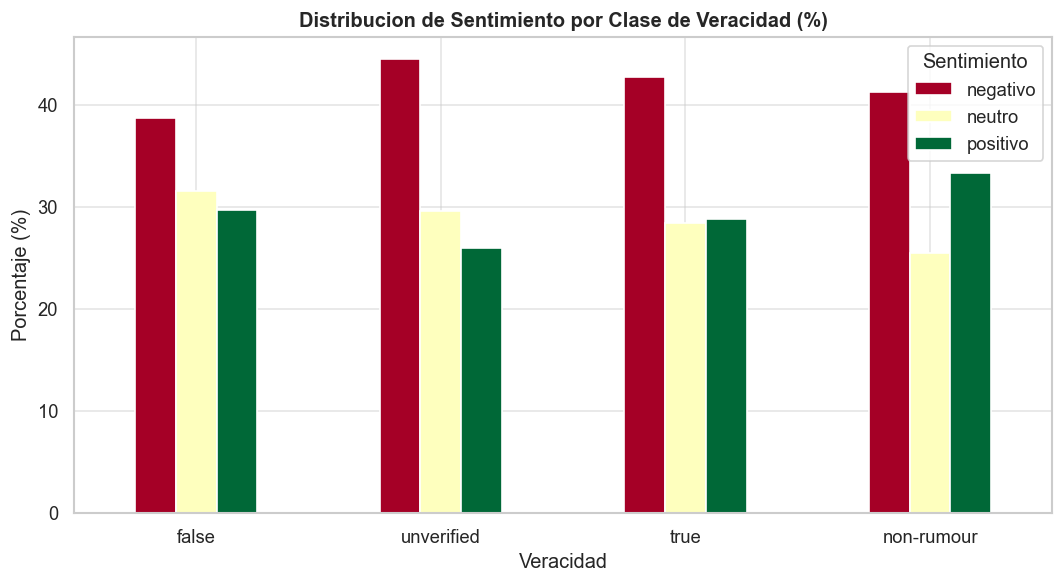

Distribucion de sentimiento por clase (%):
sentiment   negativo  neutro  positivo
veracity                              
false           38.7    31.6      29.7
unverified      44.5    29.6      25.9
true            42.8    28.4      28.8
non-rumour      41.3    25.5      33.3


In [6]:
# Clasificacion de sentimiento
def classify_sentiment(compound):
    if compound >= 0.05:
        return 'positivo'
    elif compound <= -0.05:
        return 'negativo'
    else:
        return 'neutro'

df['sentiment'] = df['vader_compound'].apply(classify_sentiment)

# Distribucion de sentimiento por clase
pivot = pd.crosstab(df['veracity'], df['sentiment'], normalize='index') * 100
pivot = pivot.reindex(ver_order)

fig, ax = plt.subplots(figsize=(9, 5))
pivot.plot(kind='bar', ax=ax, colormap='RdYlGn', edgecolor='white')
ax.set_title('Distribucion de Sentimiento por Clase de Veracidad (%)',
             fontweight='bold')
ax.set_xlabel('Veracidad')
ax.set_ylabel('Porcentaje (%)')
ax.legend(title='Sentimiento')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '23_sentiment_distribution.png'), bbox_inches='tight')
plt.show()

print('Distribucion de sentimiento por clase (%):')
print(pivot.round(1).to_string())

## 4. Análisis de subjetividad con TextBlob

In [7]:
def get_textblob_scores(text: str) -> dict:
    """
    TextBlob proporciona:
    - polarity:     [-1, 1] negativo a positivo
    - subjectivity: [0, 1]  objetivo a subjetivo
    """
    blob = TextBlob(str(text))
    return {
        'tb_polarity':     blob.sentiment.polarity,
        'tb_subjectivity': blob.sentiment.subjectivity,
    }

print('Calculando scores TextBlob...')
tb_scores = [get_textblob_scores(t) for t in tqdm(df['text'], desc='TextBlob')]
df_tb     = pd.DataFrame(tb_scores)
df        = pd.concat([df, df_tb], axis=1)

print('Hecho.')
print(df.groupby('veracity')[['tb_polarity', 'tb_subjectivity']].mean().round(3).to_string())

Calculando scores TextBlob...


TextBlob: 100%|██████████| 96936/96936 [00:07<00:00, 12911.09it/s]


Hecho.
            tb_polarity  tb_subjectivity
veracity                                
false             0.012            0.332
non-rumour        0.032            0.353
true              0.012            0.345
unverified        0.016            0.319


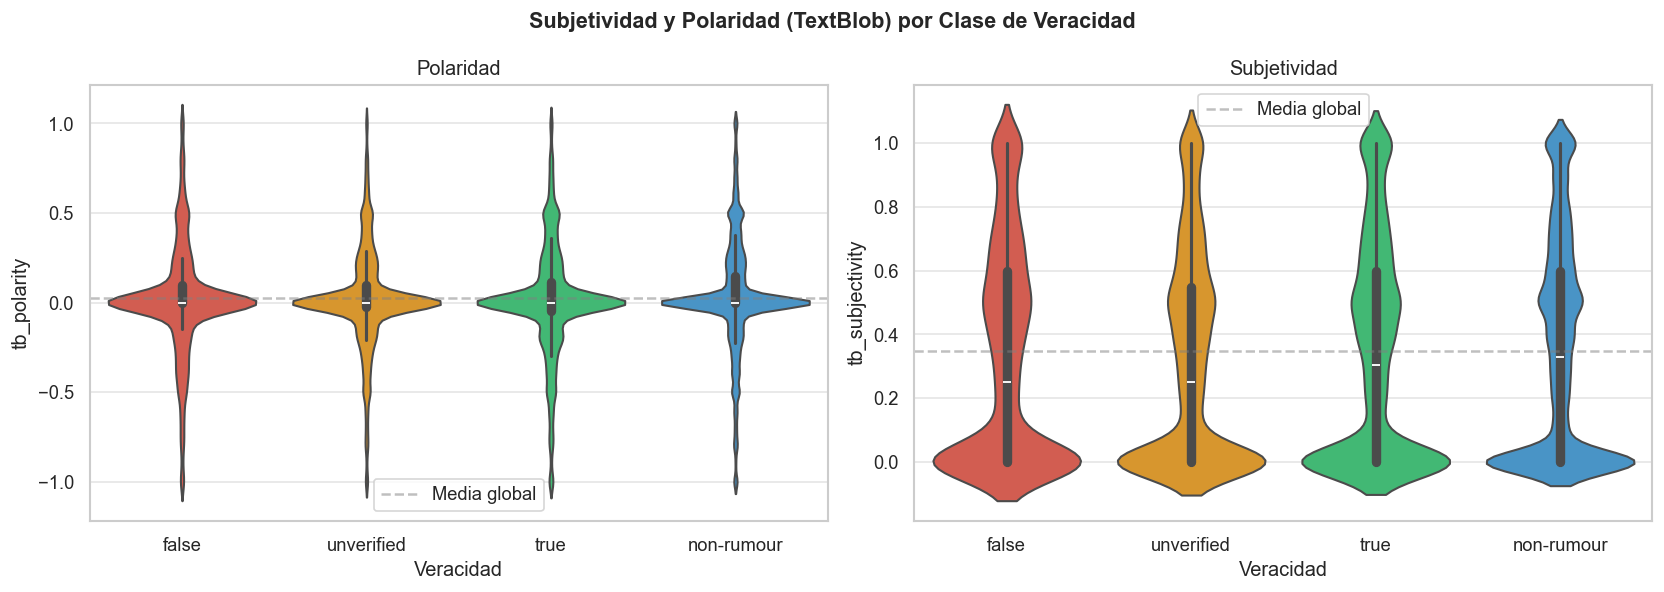

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Subjetividad y Polaridad (TextBlob) por Clase de Veracidad',
             fontsize=13, fontweight='bold')

for ax, (col, title) in zip(axes, [('tb_polarity', 'Polaridad'), ('tb_subjectivity', 'Subjetividad')]):
    sns.violinplot(data=df, x='veracity', y=col, order=ver_order,
                   palette=palette, ax=ax, inner='box')
    ax.set_title(title)
    ax.set_xlabel('Veracidad')
    ax.set_ylabel(col)
    ax.axhline(y=df[col].mean(), color='gray', linestyle='--', alpha=0.5, label='Media global')
    ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '24_textblob_analysis.png'), bbox_inches='tight')
plt.show()

## 5. Tests estadísticos

In [9]:
# Kruskal-Wallis: test no parametrico para comparar distribuciones entre clases
print('TEST DE KRUSKAL-WALLIS')
print('Hipotesis nula: no hay diferencias en la distribucion entre clases')
print('-' * 60)

metrics_to_test = [
    ('vader_neg',      'Negatividad VADER'),
    ('vader_compound', 'Compound VADER'),
    ('tb_subjectivity','Subjetividad TextBlob'),
    ('tb_polarity',    'Polaridad TextBlob'),
]

groups = [df[df['veracity'] == v] for v in ver_order]

for col, name in metrics_to_test:
    samples = [g[col].dropna().values for g in groups]
    stat, p  = kruskal(*samples)
    sig      = '*** p<0.001' if p < 0.001 else ('** p<0.01' if p < 0.01 else ('* p<0.05' if p < 0.05 else 'ns'))
    print(f'{name:30s} H={stat:.2f}  p={p:.4f}  {sig}')

print()
print('*** = diferencia altamente significativa')

# Mann-Whitney: false vs true (comparacion directa)
print()
print('MANN-WHITNEY U — false vs true:')
print('-' * 60)
false_group = df[df['veracity'] == 'false']
true_group  = df[df['veracity'] == 'true']

if len(false_group) > 0 and len(true_group) > 0:
    for col, name in metrics_to_test:
        stat, p = mannwhitneyu(
            false_group[col].dropna(),
            true_group[col].dropna(),
            alternative='two-sided'
        )
        sig = '*** p<0.001' if p < 0.001 else ('** p<0.01' if p < 0.01 else ('* p<0.05' if p < 0.05 else 'ns'))
        print(f'{name:30s} U={stat:.0f}  p={p:.4f}  {sig}')

TEST DE KRUSKAL-WALLIS
Hipotesis nula: no hay diferencias en la distribucion entre clases
------------------------------------------------------------
Negatividad VADER              H=43.61  p=0.0000  *** p<0.001
Compound VADER                 H=201.81  p=0.0000  *** p<0.001
Subjetividad TextBlob          H=103.65  p=0.0000  *** p<0.001
Polaridad TextBlob             H=108.32  p=0.0000  *** p<0.001

*** = diferencia altamente significativa

MANN-WHITNEY U — false vs true:
------------------------------------------------------------
Negatividad VADER              U=39438316  p=0.0000  *** p<0.001
Compound VADER                 U=43341525  p=0.0000  *** p<0.001
Subjetividad TextBlob          U=40766125  p=0.0130  * p<0.05
Polaridad TextBlob             U=41606134  p=0.8742  ns


## 6. Análisis léxico de polarización

In [10]:
# Indicadores linguisticos de polarizacion
STOP_WORDS = set(stopwords.words('english'))
STOP_WORDS.update(['rt', 'http', 'https', 'amp', 'via', 'co'])

# Palabras de alta carga emocional negativa (segun literatura)
NEGATIVE_WORDS = {
    'shooting', 'killed', 'dead', 'attack', 'bomb', 'terror', 'fear',
    'hate', 'lie', 'fake', 'hoax', 'conspiracy', 'dangerous', 'threat',
    'explosion', 'murder', 'violence', 'crisis', 'death', 'fatal'
}

# Palabras de alarma/urgencia tipicas de desinformacion
ALARM_WORDS = {
    'breaking', 'urgent', 'alert', 'warning', 'share', 'viral',
    'exclusive', 'shocking', 'unbelievable', 'must', 'now', 'immediately'
}

def count_indicators(text: str) -> dict:
    text_lower = str(text).lower()
    tokens     = word_tokenize(re.sub(r'[^a-z\s]', '', text_lower))

    n_exclamation = text.count('!')
    n_caps_words  = len([w for w in text.split() if w.isupper() and len(w) > 2])
    n_negative    = sum(1 for t in tokens if t in NEGATIVE_WORDS)
    n_alarm       = sum(1 for t in tokens if t in ALARM_WORDS)
    n_words       = max(len(tokens), 1)

    return {
        'n_exclamation':   n_exclamation,
        'n_caps_words':    n_caps_words,
        'n_negative':      n_negative,
        'n_alarm':         n_alarm,
        'ratio_negative':  n_negative / n_words,
        'ratio_alarm':     n_alarm    / n_words,
        'polarization_score': (n_exclamation + n_caps_words * 2 +
                               n_negative + n_alarm * 2) / n_words,
    }

print('Calculando indicadores linguisticos...')
indicators = [count_indicators(t) for t in tqdm(df['text'], desc='Indicadores')]
df_ind     = pd.DataFrame(indicators)
df         = pd.concat([df, df_ind], axis=1)

print('Hecho.')
print(df.groupby('veracity')[['ratio_negative', 'ratio_alarm', 'polarization_score', 'n_caps_words']].mean().round(4).to_string())

Calculando indicadores linguisticos...


Indicadores: 100%|██████████| 96936/96936 [00:02<00:00, 32666.58it/s]


Hecho.
            ratio_negative  ratio_alarm  polarization_score  n_caps_words
veracity                                                                 
false               0.0083       0.0074              0.1211        0.4860
non-rumour          0.0071       0.0036              0.0877        0.3671
true                0.0100       0.0072              0.1268        0.5332
unverified          0.0086       0.0055              0.1022        0.4555


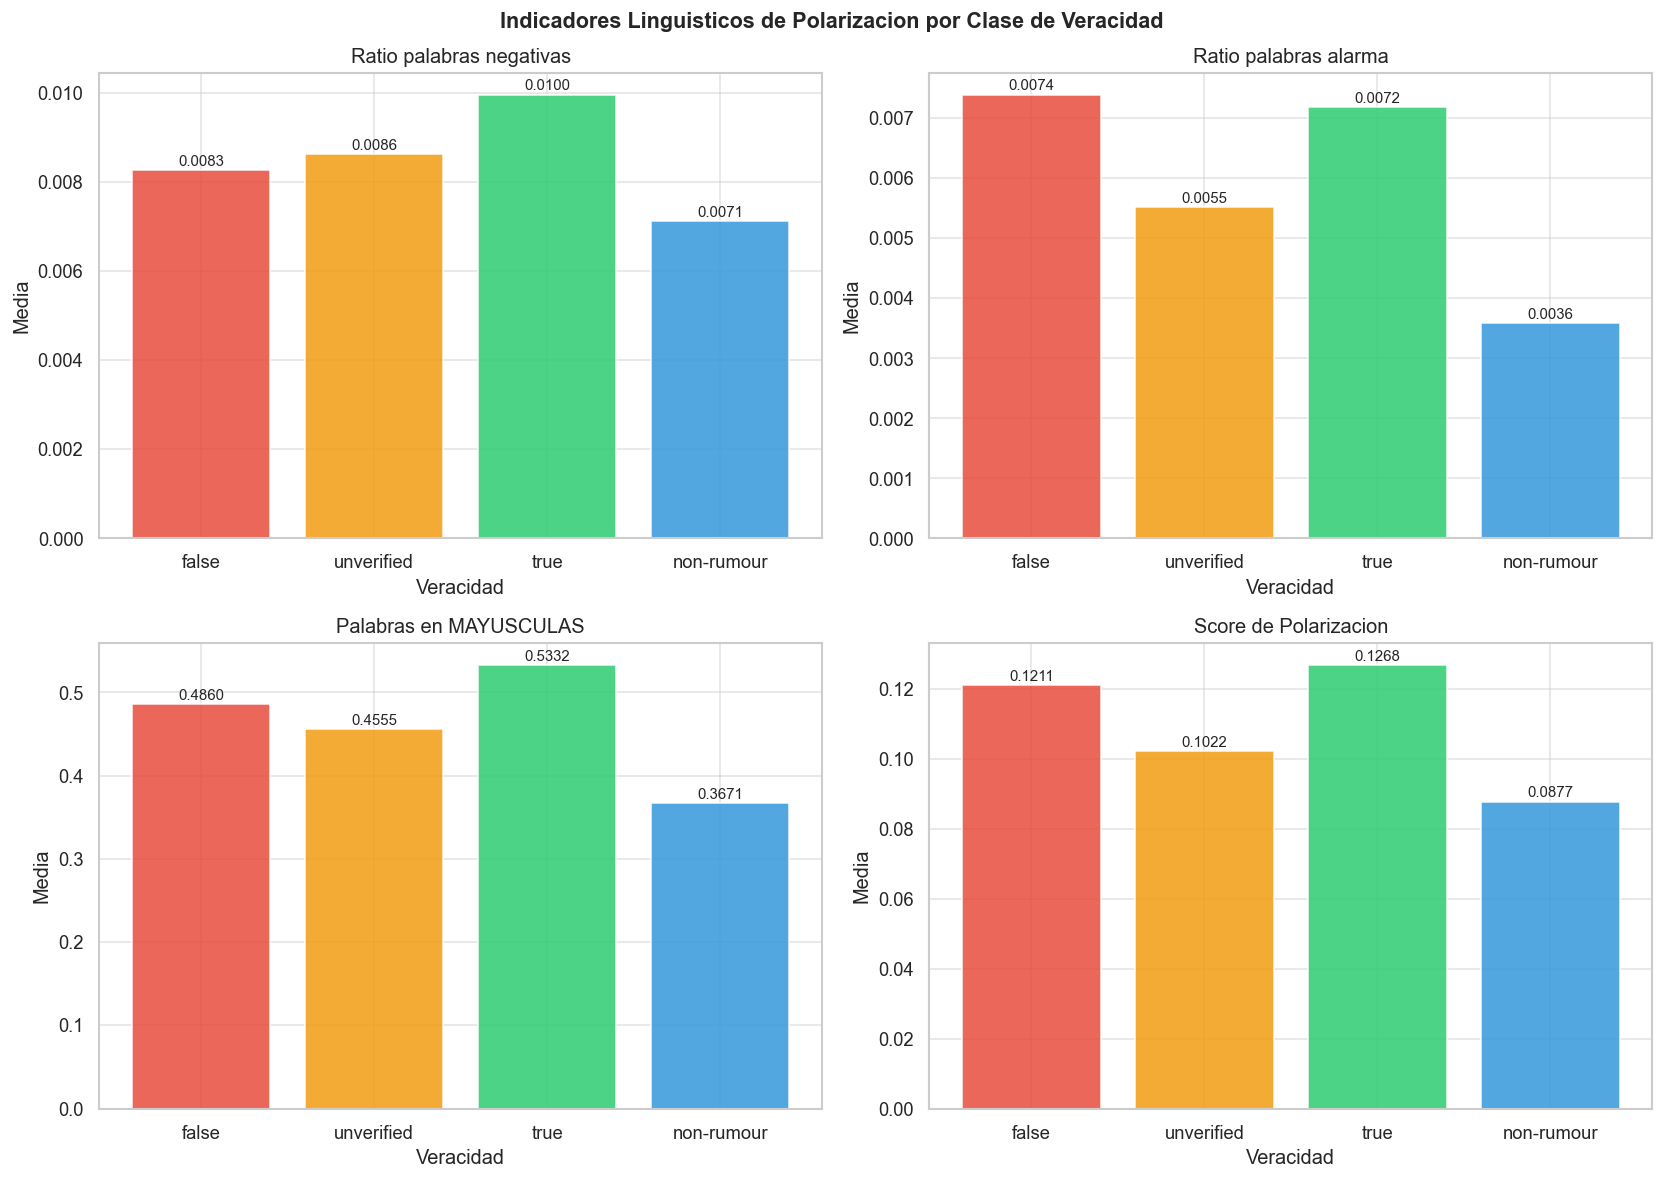

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Indicadores Linguisticos de Polarizacion por Clase de Veracidad',
             fontsize=13, fontweight='bold')

indicators_plot = [
    ('ratio_negative',    'Ratio palabras negativas', axes[0, 0]),
    ('ratio_alarm',       'Ratio palabras alarma',    axes[0, 1]),
    ('n_caps_words',      'Palabras en MAYUSCULAS',   axes[1, 0]),
    ('polarization_score','Score de Polarizacion',    axes[1, 1]),
]

for col, title, ax in indicators_plot:
    means = df.groupby('veracity')[col].mean().reindex(ver_order)
    bars  = ax.bar(means.index, means.values,
                   color=[CLASS_COLORS[v] for v in means.index], alpha=0.85)
    ax.set_title(title)
    ax.set_xlabel('Veracidad')
    ax.set_ylabel('Media')
    for bar, val in zip(bars, means.values):
        ax.text(bar.get_x() + bar.get_width()/2, val + means.max()*0.01,
                f'{val:.4f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '25_polarization_indicators.png'), bbox_inches='tight')
plt.show()

## 7. Correlación entre desinformación y carga emocional

In [12]:
# Variable binaria: rumour (1) vs non-rumour (0)
df['is_rumour_bin'] = (df['rumour_type'] == 'rumours').astype(int)

# Correlaciones de Spearman (no asume normalidad)
print('CORRELACIONES DE SPEARMAN — desinformacion vs carga emocional')
print('(is_rumour_bin: 1=rumour, 0=non-rumour)')
print('-' * 60)

emotion_cols = [
    'vader_neg', 'vader_pos', 'vader_compound',
    'tb_polarity', 'tb_subjectivity',
    'polarization_score', 'ratio_negative', 'ratio_alarm'
]

correlations = []
for col in emotion_cols:
    r, p = stats.spearmanr(df['is_rumour_bin'], df[col].fillna(0))
    sig  = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    correlations.append({'Variable': col, 'Spearman r': r, 'p-value': p, 'Sig': sig})
    print(f'{col:25s}  r={r:+.4f}  p={p:.4f}  {sig}')

df_corr = pd.DataFrame(correlations).sort_values('Spearman r', key=abs, ascending=False)

CORRELACIONES DE SPEARMAN — desinformacion vs carga emocional
(is_rumour_bin: 1=rumour, 0=non-rumour)
------------------------------------------------------------
vader_neg                  r=+0.0027  p=0.3985  ns
vader_pos                  r=-0.0708  p=0.0000  ***
vader_compound             r=-0.0393  p=0.0000  ***
tb_polarity                r=-0.0334  p=0.0000  ***
tb_subjectivity            r=-0.0280  p=0.0000  ***
polarization_score         r=+0.0783  p=0.0000  ***
ratio_negative             r=+0.0324  p=0.0000  ***
ratio_alarm                r=+0.0759  p=0.0000  ***


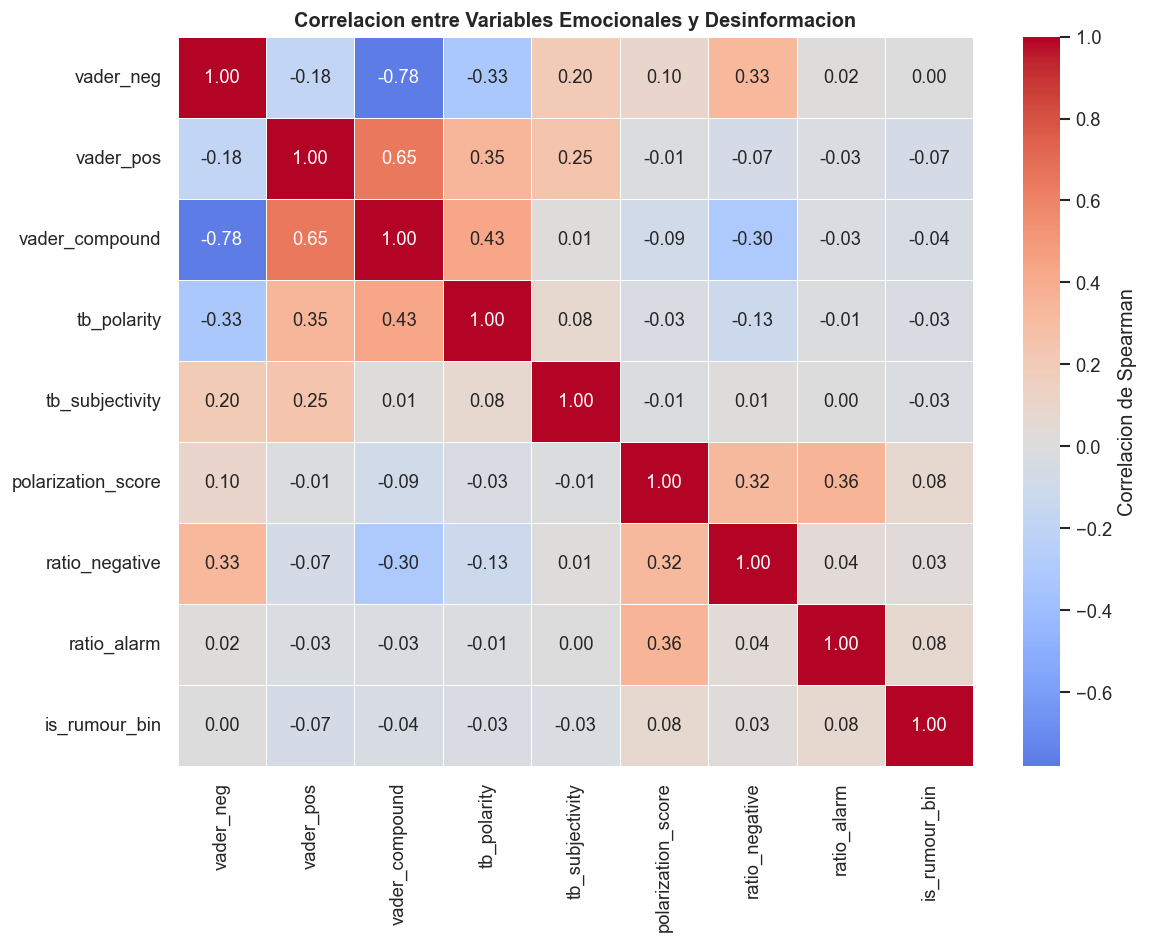

In [13]:
# Heatmap de correlaciones entre variables emocionales y veracidad
emotion_cols_ext = emotion_cols + ['is_rumour_bin']
corr_matrix = df[emotion_cols_ext].corr(method='spearman')

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5,
            cbar_kws={'label': 'Correlacion de Spearman'})
ax.set_title('Correlacion entre Variables Emocionales y Desinformacion',
             fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '26_correlation_heatmap.png'), bbox_inches='tight')
plt.show()

## 8. Análisis por evento

CARGA EMOCIONAL POR EVENTO:
                   vader_compound_mean  vader_neg_mean  subjectivity_mean  polarization_mean  pct_rumour  n_tweets
event                                                                                                             
charliehebdo                    -0.100           0.136              0.339              0.093       0.191     35378
ebola-essien                    -0.017           0.128              0.426              0.092       1.000       190
ferguson                        -0.073           0.116              0.341              0.093       0.271     22163
germanwings-crash               -0.119           0.126              0.328              0.126       0.560      4003
gurlitt                          0.157           0.040              0.265              0.053       0.488       172
ottawashooting                  -0.058           0.126              0.361              0.111       0.522     11230
prince-toronto                   0.139           0.0

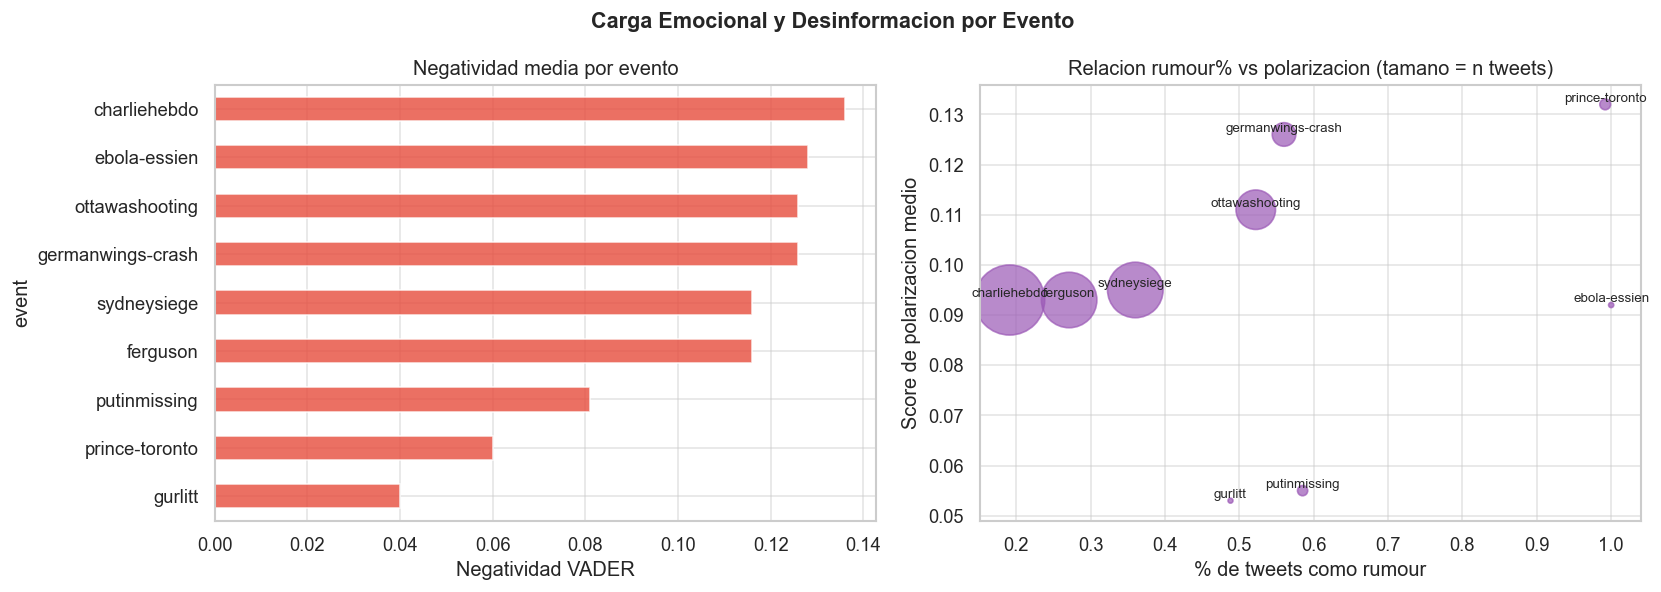

In [14]:
# Carga emocional por evento
event_emotion = df.groupby('event').agg(
    vader_compound_mean  = ('vader_compound',    'mean'),
    vader_neg_mean       = ('vader_neg',         'mean'),
    subjectivity_mean    = ('tb_subjectivity',   'mean'),
    polarization_mean    = ('polarization_score','mean'),
    pct_rumour           = ('is_rumour_bin',     'mean'),
    n_tweets             = ('text',              'count'),
).round(3)

print('CARGA EMOCIONAL POR EVENTO:')
print(event_emotion.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Carga Emocional y Desinformacion por Evento', fontsize=13, fontweight='bold')

event_emotion.sort_values('vader_neg_mean', ascending=True).plot(
    kind='barh', y='vader_neg_mean', ax=axes[0], color='#e74c3c', alpha=0.8, legend=False
)
axes[0].set_title('Negatividad media por evento')
axes[0].set_xlabel('Negatividad VADER')

axes[1].scatter(
    event_emotion['pct_rumour'],
    event_emotion['polarization_mean'],
    s=event_emotion['n_tweets'] / 20,
    alpha=0.7, color='#9b59b6'
)
for event, row in event_emotion.iterrows():
    axes[1].annotate(event, (row['pct_rumour'], row['polarization_mean']),
                     fontsize=8, ha='center', va='bottom')
axes[1].set_xlabel('% de tweets como rumour')
axes[1].set_ylabel('Score de polarizacion medio')
axes[1].set_title('Relacion rumour% vs polarizacion (tamano = n tweets)')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '27_emotion_by_event.png'), bbox_inches='tight')
plt.show()

## 9. Perfil emocional completo por clase

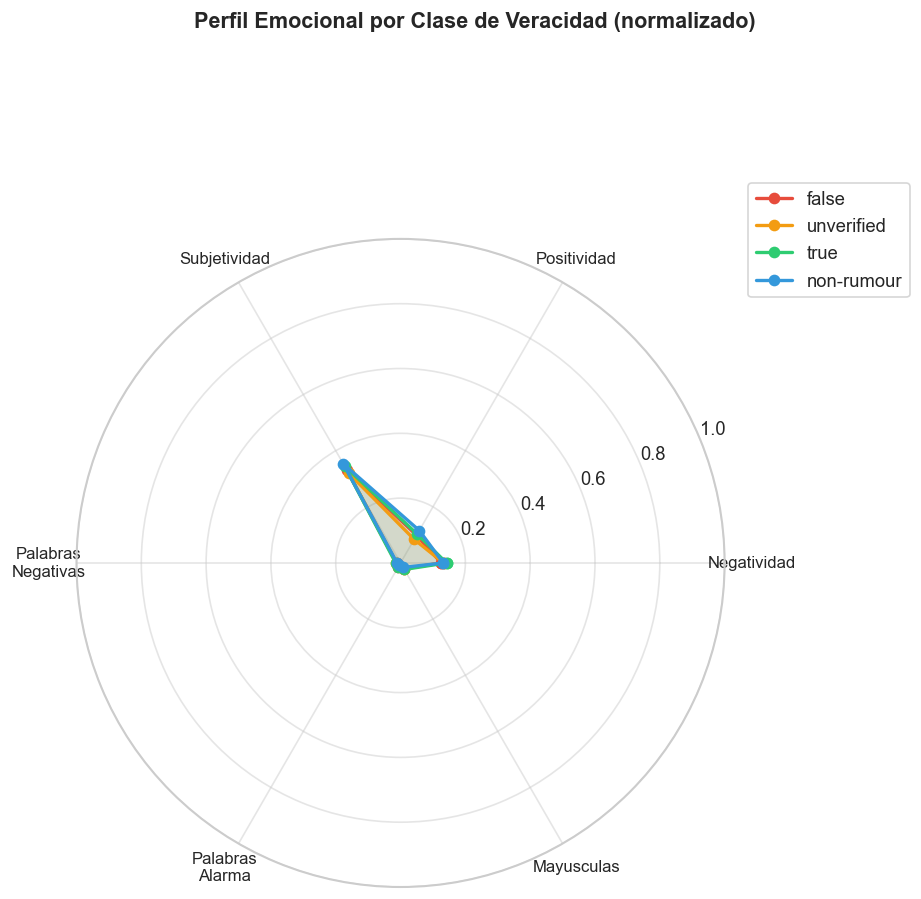

In [15]:
# Radar chart: perfil emocional por clase
from matplotlib.patches import FancyArrowPatch

profile_cols = [
    'vader_neg', 'vader_pos', 'tb_subjectivity',
    'ratio_negative', 'ratio_alarm', 'n_caps_words'
]
profile_labels = [
    'Negatividad', 'Positividad', 'Subjetividad',
    'Palabras\nNegativas', 'Palabras\nAlarma', 'Mayusculas'
]

# Normalizar columnas a [0,1]
df_norm = df.copy()
for col in profile_cols:
    col_min = df[col].min()
    col_max = df[col].max()
    if col_max > col_min:
        df_norm[col] = (df[col] - col_min) / (col_max - col_min)

profile = df_norm.groupby('veracity')[profile_cols].mean().reindex(ver_order)

# Radar chart
N     = len(profile_cols)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
fig.suptitle('Perfil Emocional por Clase de Veracidad (normalizado)',
             fontsize=13, fontweight='bold', y=1.02)

for ver in ver_order:
    if ver not in profile.index:
        continue
    values = profile.loc[ver].values.tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2,
            label=ver, color=CLASS_COLORS[ver])
    ax.fill(angles, values, alpha=0.1, color=CLASS_COLORS[ver])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(profile_labels, fontsize=10)
ax.set_ylim(0, 1)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '28_radar_emotional_profile.png'), bbox_inches='tight')
plt.show()

## 10. Conclusiones — Hipótesis H4

In [16]:
print('=' * 65)
print('CONCLUSIONES — HIPOTESIS H4')
print('Los contenidos desinformativos presentan mayor carga')
print('emocional negativa y signos linguisticos de polarizacion')
print('que los contenidos verdaderos.')
print('=' * 65)

print('\n1. SENTIMIENTO (VADER):')
neg_by_class = df.groupby('veracity')['vader_neg'].mean().reindex(ver_order)
for v, val in neg_by_class.items():
    print(f'   {v:15s}: negatividad media = {val:.4f}')

print('\n2. SUBJETIVIDAD (TextBlob):')
sub_by_class = df.groupby('veracity')['tb_subjectivity'].mean().reindex(ver_order)
for v, val in sub_by_class.items():
    print(f'   {v:15s}: subjetividad media = {val:.4f}')

print('\n3. POLARIZACION LEXICA:')
pol_by_class = df.groupby('veracity')['polarization_score'].mean().reindex(ver_order)
for v, val in pol_by_class.items():
    print(f'   {v:15s}: score polarizacion = {val:.4f}')

print('\n4. SIGNIFICACION ESTADISTICA:')
print('   Tests Kruskal-Wallis y Mann-Whitney realizados en seccion 5.')

print('\n5. CORRELACION:')
print(df_corr[['Variable', 'Spearman r', 'Sig']].to_string(index=False))

print('\n6. VEREDICTO H4:')
false_neg  = df[df['veracity']=='false']['vader_neg'].mean() if 'false' in df['veracity'].values else 0
true_neg   = df[df['veracity']=='true']['vader_neg'].mean()  if 'true'  in df['veracity'].values else 0
false_pol  = df[df['veracity']=='false']['polarization_score'].mean() if 'false' in df['veracity'].values else 0
true_pol   = df[df['veracity']=='true']['polarization_score'].mean()  if 'true'  in df['veracity'].values else 0

if false_neg > true_neg:
    print('   CONFIRMADA: los tweets falsos presentan mayor negatividad')
    print(f'   que los verdaderos ({false_neg:.4f} vs {true_neg:.4f})')
else:
    print('   PARCIALMENTE CONFIRMADA: los patrones son complejos')
    print(f'   Negatividad false={false_neg:.4f} vs true={true_neg:.4f}')

print()
print('Ficheros guardados en results/:')
for f in sorted(os.listdir(RESULTS_DIR)):
    if f.startswith('2'):
        print(f'  {f}')

CONCLUSIONES — HIPOTESIS H4
Los contenidos desinformativos presentan mayor carga
emocional negativa y signos linguisticos de polarizacion
que los contenidos verdaderos.

1. SENTIMIENTO (VADER):
   false          : negatividad media = 0.1171
   unverified     : negatividad media = 0.1237
   true           : negatividad media = 0.1324
   non-rumour     : negatividad media = 0.1229

2. SUBJETIVIDAD (TextBlob):
   false          : subjetividad media = 0.3320
   unverified     : subjetividad media = 0.3195
   true           : subjetividad media = 0.3453
   non-rumour     : subjetividad media = 0.3530

3. POLARIZACION LEXICA:
   false          : score polarizacion = 0.1211
   unverified     : score polarizacion = 0.1022
   true           : score polarizacion = 0.1268
   non-rumour     : score polarizacion = 0.0877

4. SIGNIFICACION ESTADISTICA:
   Tests Kruskal-Wallis y Mann-Whitney realizados en seccion 5.

5. CORRELACION:
          Variable  Spearman r Sig
polarization_score    0.078294 **